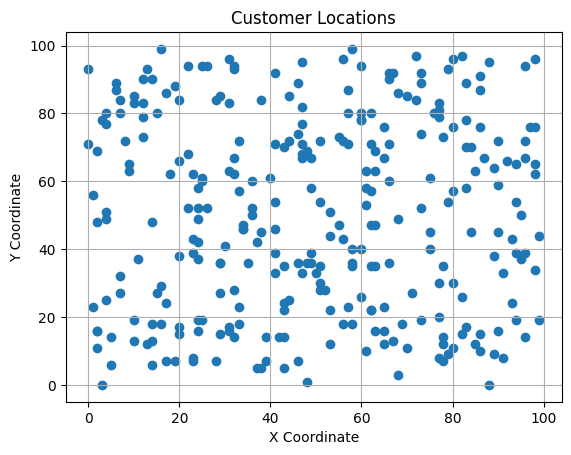

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# 300 müşterinin rastgele koordinatları
customers = np.random.randint(0, 100, (300, 2))

# x ve y koordinatları
x = customers[:, 0]
y = customers[:, 1]

# grafiği çiz
plt.scatter(x, y)

plt.title("Customer Locations")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.grid(True)
plt.show()

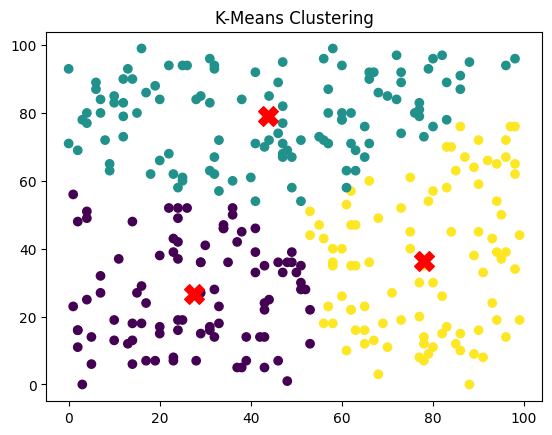

In [20]:
from sklearn.cluster import KMeans

# depo sayısı
k = 3

# K-Means modeli
kmeans = KMeans(n_clusters=k)

# modeli eğit
kmeans.fit(customers)

# kümeler
labels = kmeans.labels_

# merkezler
centers = kmeans.cluster_centers_

# müşterileri çiz
plt.scatter(x, y, c=labels)

# küme merkezlerini çiz
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    color='red',
    marker='X',
    s=200
)

plt.title("K-Means Clustering")
plt.show()

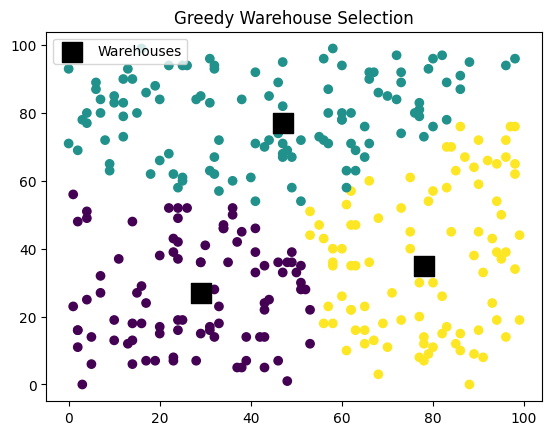

In [21]:
from scipy.spatial.distance import cdist

warehouses = []

# Her küme için işlem yap
for i in range(k):

    # O kümeye ait müşteriler
    cluster_points = customers[labels == i]

    # Küme merkezi
    center = centers[i].reshape(1, -1)

    # Merkeze uzaklıklar
    distances = cdist(cluster_points, center)

    # En yakın müşteri
    nearest_index = distances.argmin()

    # Depo noktası
    warehouse = cluster_points[nearest_index]

    warehouses.append(warehouse)

# numpy array yap
warehouses = np.array(warehouses)

# müşterileri çiz
plt.scatter(x, y, c=labels)

# depoları çiz
plt.scatter(
    warehouses[:,0],
    warehouses[:,1],
    color='black',
    marker='s',
    s=200,
    label='Warehouses'
)

plt.legend()
plt.title("Greedy Warehouse Selection")
plt.show()

In [22]:
total_cost = 0

for i in range(k):

    # kümedeki müşteriler
    cluster_points = customers[labels == i]

    # o kümenin deposu
    warehouse = warehouses[i]

    # tüm müşterilerin depoya uzaklığı
    distances = cdist(cluster_points, [warehouse])

    # toplam maliyete ekle
    total_cost += distances.sum()

print("Total Cost:", total_cost)

Total Cost: 6992.2726127509795


In [23]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import numpy as np

# Sonuçları saklamak için
k_values = [2, 3, 4, 5, 6, 7, 8]
costs = []

# Her bir depo açılışı için sisteme 500 birim maliyet ekliyoruz
FIXED_OPENING_COST = 500

for k in k_values:

    # K-Means
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(customers)

    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    warehouses = []

    # Greedy depo seçimi
    for i in range(k):
        cluster_points = customers[labels == i]
        center = centers[i].reshape(1, -1)
        distances = cdist(cluster_points, center)
        nearest_index = distances.argmin()
        warehouse = cluster_points[nearest_index]
        warehouses.append(warehouse)

    warehouses = np.array(warehouses)


    # Önce sadece mesafe maliyetini hesaplamak için bir değişken açıyoruz
    distance_cost = 0

    for i in range(k):
        cluster_points = customers[labels == i]
        warehouse = warehouses[i]
        distances = cdist(cluster_points, [warehouse])
        distance_cost += distances.sum() # Tüm müşterilerin depolara olan mesafesi


    total_cost = distance_cost + (k * FIXED_OPENING_COST)

    # Listeye bu yeni toplam maliyeti ekliyoruz
    costs.append(total_cost)

    print(f"K = {k} -> Mesafe: {distance_cost:.2f} | Sabit: {k * FIXED_OPENING_COST} | Toplam Cost = {total_cost:.2f}")

K = 2 -> Mesafe: 8552.42 | Sabit: 1000 | Toplam Cost = 9552.42
K = 3 -> Mesafe: 6891.03 | Sabit: 1500 | Toplam Cost = 8391.03
K = 4 -> Mesafe: 5681.80 | Sabit: 2000 | Toplam Cost = 7681.80
K = 5 -> Mesafe: 5106.80 | Sabit: 2500 | Toplam Cost = 7606.80
K = 6 -> Mesafe: 4565.31 | Sabit: 3000 | Toplam Cost = 7565.31
K = 7 -> Mesafe: 4226.07 | Sabit: 3500 | Toplam Cost = 7726.07
K = 8 -> Mesafe: 3884.82 | Sabit: 4000 | Toplam Cost = 7884.82


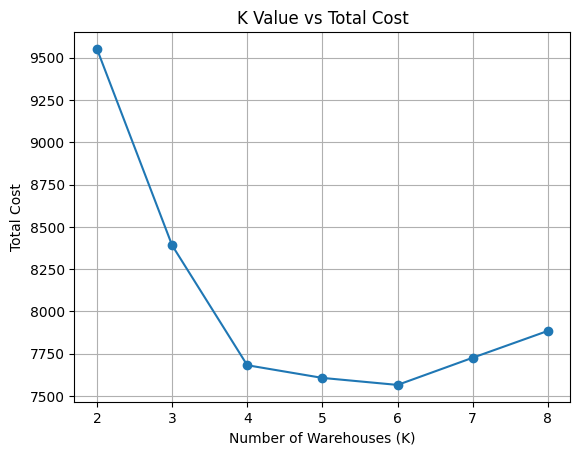

In [24]:
plt.plot(k_values, costs, marker='o')

plt.title("K Value vs Total Cost")
plt.xlabel("Number of Warehouses (K)")
plt.ylabel("Total Cost")

plt.grid(True)
plt.show()

In [25]:
import random
from scipy.spatial.distance import cdist

FIXED_OPENING_COST = 500

# Random Search için K değeri
k = 8

# Rastgele seçilen depolar
random_indices = random.sample(range(len(customers)), k)
random_warehouses = customers[random_indices]

# 1. Önce mesafe maliyetini sıfırlayarak başlıyoruz
random_distance_cost = 0

for customer in customers:
    # Müşterinin tüm depolara uzaklığı
    distances = cdist([customer], random_warehouses)

    # En yakın depo
    nearest_distance = distances.min()

    # Sadece mesafeleri topluyoruz
    random_distance_cost += nearest_distance

random_total_cost = random_distance_cost + (k * FIXED_OPENING_COST)

print(f"Random Search -> Mesafe: {random_distance_cost:.2f} | Sabit: {k * FIXED_OPENING_COST} | Toplam Cost = {random_total_cost:.2f}")

Random Search -> Mesafe: 7280.72 | Sabit: 4000 | Toplam Cost = 11280.72


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

# K değerleri
k_values = [2, 3, 4, 5, 6, 7, 8]
FIXED_OPENING_COST = 500

# Sonuç listeleri
hybrid_costs = []
random_costs = []

for k in k_values:

    # 1. HYBRID ALGORITHM
    kmeans = KMeans(n_clusters=k, random_state=42) # random_state kararlılık sağlar
    kmeans.fit(customers)

    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    warehouses = []
    # Greedy warehouse selection
    for i in range(k):
        cluster_points = customers[labels == i]
        center = centers[i].reshape(1, -1)
        distances = cdist(cluster_points, center)
        nearest_index = distances.argmin()
        warehouse = cluster_points[nearest_index]
        warehouses.append(warehouse)

    warehouses = np.array(warehouses)

    # Hybrid mesafe maliyeti
    hybrid_distance_cost = 0
    for i in range(k):
        cluster_points = customers[labels == i]
        warehouse = warehouses[i]
        distances = cdist(cluster_points, [warehouse])
        hybrid_distance_cost += distances.sum()

    # Hibrit Toplam Maliyet
    hybrid_total_cost = hybrid_distance_cost + (k * FIXED_OPENING_COST)
    hybrid_costs.append(hybrid_total_cost)


    # 2. RANDOM SEARCH (100 Deneme)
    best_random_cost = float('inf')
    random_trial_costs = []

    for _ in range(100):
        random_indices = random.sample(range(len(customers)), k)
        random_warehouses = customers[random_indices]

        # Vektörel hızlı mesafe hesaplama
        distances_matrix = cdist(customers, random_warehouses)
        random_distance_cost = distances_matrix.min(axis=1).sum()

        # Her denemenin toplam maliyeti
        trial_total_cost = random_distance_cost + (k * FIXED_OPENING_COST)
        random_trial_costs.append(trial_total_cost)

        if trial_total_cost < best_random_cost:
            best_random_cost = trial_total_cost

    # 100 denemenin ortalama TOPLAM maliyetini hesapla
    avg_random_cost = np.mean(random_trial_costs)
    random_costs.append(avg_random_cost)

    print(f"K = {k}")
    print(f"Hybrid Total Cost: {hybrid_total_cost:.2f} (Mesafe: {hybrid_distance_cost:.2f} + Sabit: {k*FIXED_OPENING_COST})")
    print(f"Random Search (Ortalama): {avg_random_cost:.2f}")
    print(f"Random Search (En İyi Deneme): {best_random_cost:.2f}")
    print("----------------------------")

K = 2
Hybrid Total Cost: 9552.42 (Mesafe: 8552.42 + Sabit: 1000)
Random Search (Ortalama): 12415.47
Random Search (En İyi Deneme): 9712.90
----------------------------
K = 3
Hybrid Total Cost: 8408.48 (Mesafe: 6908.48 + Sabit: 1500)
Random Search (Ortalama): 10582.10
Random Search (En İyi Deneme): 8575.41
----------------------------
K = 4
Hybrid Total Cost: 7633.73 (Mesafe: 5633.73 + Sabit: 2000)
Random Search (Ortalama): 9913.87
Random Search (En İyi Deneme): 8363.57
----------------------------
K = 5
Hybrid Total Cost: 7503.05 (Mesafe: 5003.05 + Sabit: 2500)
Random Search (Ortalama): 9667.90
Random Search (En İyi Deneme): 8184.29
----------------------------
K = 6
Hybrid Total Cost: 7768.02 (Mesafe: 4768.02 + Sabit: 3000)
Random Search (Ortalama): 9643.70
Random Search (En İyi Deneme): 7913.96
----------------------------
K = 7
Hybrid Total Cost: 7569.75 (Mesafe: 4069.75 + Sabit: 3500)
Random Search (Ortalama): 9370.71
Random Search (En İyi Deneme): 8173.12
-------------------------

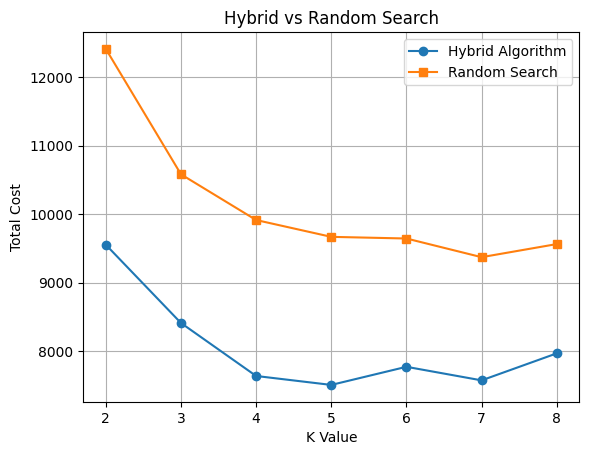

In [27]:
plt.plot(k_values, hybrid_costs, marker='o', label='Hybrid Algorithm')

plt.plot(k_values, random_costs, marker='s', label='Random Search')

plt.xlabel("K Value")
plt.ylabel("Total Cost")

plt.title("Hybrid vs Random Search")

plt.legend()
plt.grid(True)

plt.show()